In [14]:
import os
import sys

project_root = os.path.abspath("..")
sys.path.append(project_root)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [3]:
import os
os.getcwd()

'c:\\Users\\sindh\\OneDrive\\Desktop\\customer-churn-prediction\\notebooks'

In [4]:
import os

os.path.exists("data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

False

In [5]:
import os

os.path.exists("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

True

In [2]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
print(df.shape)

(7043, 21)


In [4]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [9]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
churn_counts = df["Churn"].value_counts()
print(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


C:\Users\sindh\AppData\Local\Temp\ipykernel_4800\3895508260.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


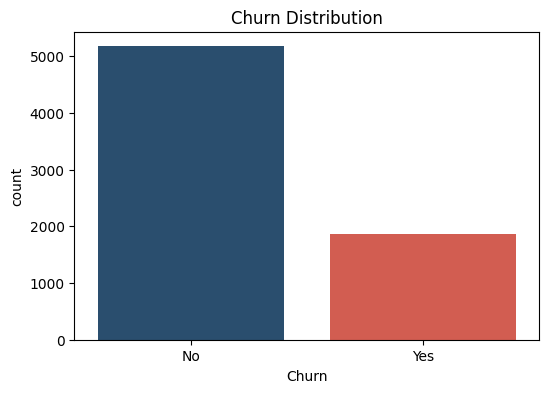

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df,
    palette=["#1F4E79", "#E74C3C"]
)

plt.title("Churn Distribution")

plt.savefig("../data/eda_churn_dist.png", dpi=150)

plt.show()

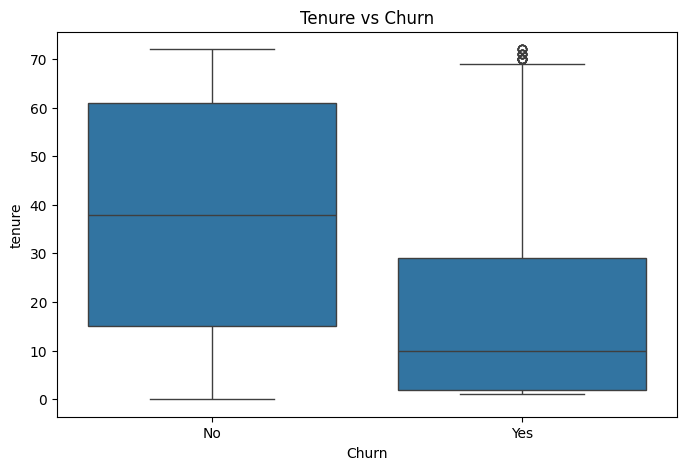

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Churn")

plt.show()

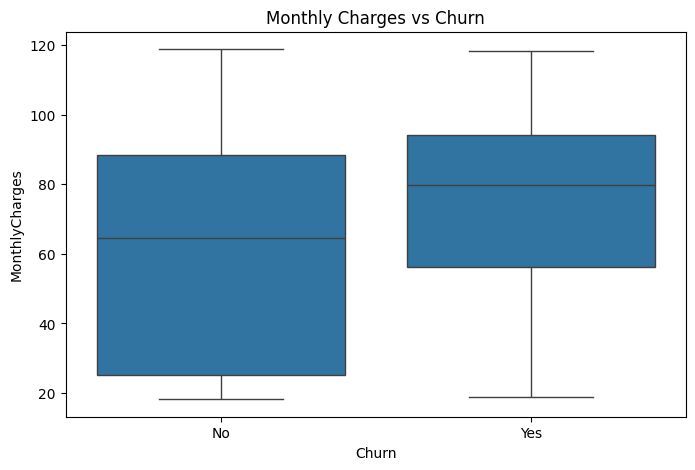

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

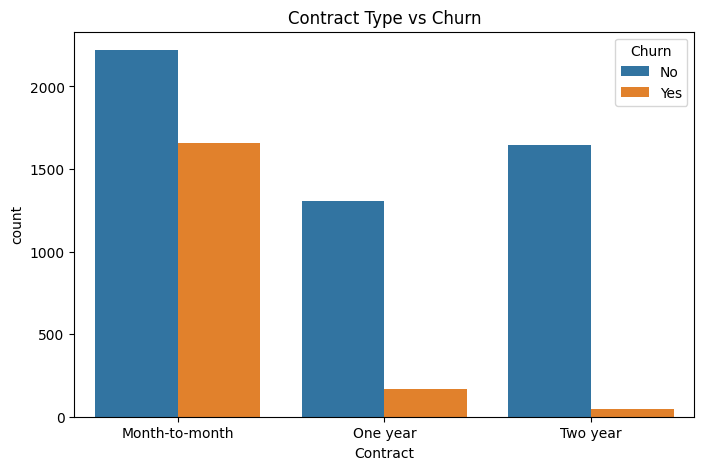

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract Type vs Churn")

plt.show()

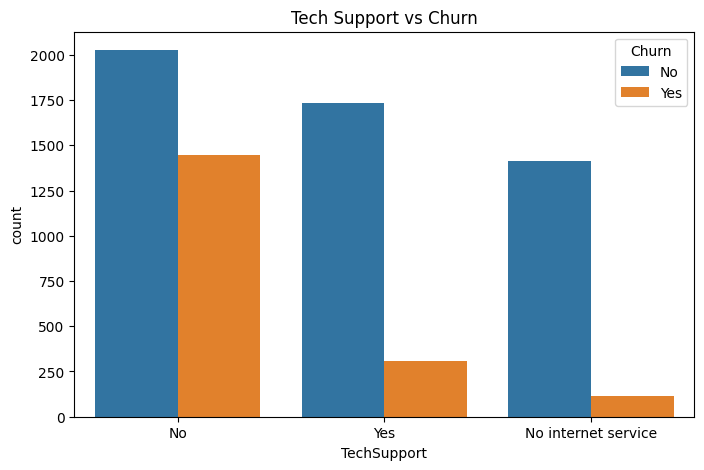

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="TechSupport",
    hue="Churn",
    data=df
)

plt.title("Tech Support vs Churn")

plt.show()

In [17]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [18]:
print(df["TotalCharges"].dtype)

float64


In [19]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

In [20]:
print(df["TotalCharges"].isnull().sum())

0


In [21]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=["new","mid","mature","loyal"],
    include_lowest=True
)

In [22]:
print(df[["tenure", "TenureGroup"]].head(10))

   tenure TenureGroup
0       1         new
1      34      mature
2       2         new
3      45      mature
4       2         new
5       8         new
6      22         mid
7      10         new
8      28      mature
9      62       loyal


In [23]:
df["AvgMonthlySpend"] = df["TotalCharges"] / (df["tenure"] + 1)

In [24]:
print(df[["TotalCharges", "tenure", "AvgMonthlySpend"]].head())

   TotalCharges  tenure  AvgMonthlySpend
0         29.85       1        14.925000
1       1889.50      34        53.985714
2        108.15       2        36.050000
3       1840.75      45        40.016304
4        151.65       2        50.550000


In [25]:
df.drop("customerID", axis=1, inplace=True)

In [26]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup',
       'AvgMonthlySpend'],
      dtype='object')


In [27]:
df = pd.get_dummies(
    df,
    columns=["InternetService", "Contract", "PaymentMethod"],
    drop_first=True
)

In [28]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TenureGroup', 'AvgMonthlySpend', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [29]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [30]:
print(X.shape)
print(y.shape)

(7043, 25)
(7043,)


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 25)
(1409, 25)
(5634,)
(1409,)


In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

ValueError: could not convert string to float: 'Male'

In [37]:
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

TenureGroup    8
dtype: int64


In [38]:
print(X_train.isnull().sum().sum())

8


In [34]:
print(X_train.select_dtypes(include="object").columns.tolist())

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']


In [12]:
from src.feature_engineering import engineer_features

ModuleNotFoundError: No module named 'src'

In [13]:
import os
print(os.getcwd())

c:\Users\sindh\OneDrive\Desktop\customer-churn-prediction\notebooks


In [15]:
from src.feature_engineering import engineer_features

In [16]:
df = engineer_features(df)

In [17]:
print(df.head())

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  ...  \
0               0             1                 0            0  ...   
1               1             0                 1            0  ...   
2               1             1                 0            0  ...   
3               1             0                 1            1  ...   
4               0             0                 0            0  ...   

   InternetService_Fiber optic  InternetService_No  Contract_One year  \
0                        False               False              False   


In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int32  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int32  
 3   Dependents                             7043 non-null   int32  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int32  
 6   OnlineSecurity                         7043 non-null   int32  
 7   OnlineBackup                           7043 non-null   int32  
 8   DeviceProtection                       7043 non-null   int32  
 9   TechSupport                            7043 non-null   int32  
 10  StreamingTV                            7043 non-null   int32  
 11  Stre

In [19]:
print(df.select_dtypes(include="object").columns)

Index([], dtype='object')


In [20]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
print(X_train.isnull().sum().sum())

0


In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

In [24]:
print(y_train.value_counts())

Churn
0    4139
1    4139
Name: count, dtype: int64
